In [14]:
#importamos libreria con pip3 install pandas en la terminal
#luego importamos aqui pandas
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\juan_\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
import pandas as pd
import numpy as np
%pip install openpyxl
pd.set_option('display.max_columns', None)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\juan_\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [16]:
#Importamos los datos de excel de cada año y los unificamos con pd.concat
df_BancaClientes2012 = pd.read_excel(r"C:\Users\juan_\Proyecto_EDA_Banco\datos\raw\customer-details.xlsx", sheet_name='2012', index_col=0)
df_BancaClientes2013 = pd.read_excel(r"C:\Users\juan_\Proyecto_EDA_Banco\datos\raw\customer-details.xlsx", sheet_name='2013', index_col=0)
df_BancaClientes2014 = pd.read_excel(r"C:\Users\juan_\Proyecto_EDA_Banco\datos\raw\customer-details.xlsx", sheet_name='2014', index_col=0)
df_BancaClientesGlobal = pd.concat([df_BancaClientes2012, df_BancaClientes2013, df_BancaClientes2014], ignore_index=True)

#Importamos los datos de csv de campañas de marketing, he observado que vienen con coma pero Python lee por puntos así que se lo indicamos
df_BancaCampañas = pd.read_csv(r"C:\Users\juan_\Proyecto_EDA_Banco\datos\raw\bank-additional.csv", index_col=0)

In [17]:
#Unificamos los datos de clientes y campañas con el ID común 
df_ClientesCampañas = pd.merge(
    df_BancaCampañas, 
    df_BancaClientesGlobal,
    left_on= "id_",
    right_on= "ID",
    how = "left"
)
print("Dimensiones finales del dataset tras JOIN:", df_ClientesCampañas.shape)
print("Comprobamos que no se han perdido datos:", df_BancaCampañas.shape)
print("Comprobamos si hay muchos nulos:", df_ClientesCampañas.isnull().sum())

Dimensiones finales del dataset tras JOIN: (43000, 29)
Comprobamos que no se han perdido datos: (43000, 23)
Comprobamos si hay muchos nulos: age                  5120
job                   345
marital                85
education            1807
default              8981
housing              1026
loan                 1026
contact                 0
duration                0
campaign                0
pdays                   0
previous                0
poutcome                0
emp.var.rate            0
cons.price.idx        471
cons.conf.idx           0
euribor3m            9256
nr.employed             0
y                       0
date                  248
latitude                0
longitude               0
id_                     0
Income                  0
Kidhome                 0
Teenhome                0
Dt_Customer             0
NumWebVisitsMonth       0
ID                      0
dtype: int64


In [18]:
#He observado que vienen unos datos como coma para decimales, para arreglarlos hacemos lo siguiente:
cols_con_comas = ['euribor3m', 'cons.price.idx', 'cons.conf.idx']

for col in cols_con_comas:
    # Convertimos a texto temporalmente para poder usar .str.replace, cambiamos coma por punto y pasamos a float
    df_ClientesCampañas[col] = df_ClientesCampañas[col].astype(str).str.replace(',', '.').astype(float)

#Modificamos los nulos de variables de texto con 'unknown'
cols_texto = ['job', 'marital', 'education', 'default', 'housing', 'loan']
df_ClientesCampañas[cols_texto] = df_ClientesCampañas[cols_texto].fillna('unknown')

#Rellenamos nulos de numéricas con la mediana puesto que es mejor que la media
df_ClientesCampañas['age'] = df_ClientesCampañas['age'].fillna(df_ClientesCampañas['age'].median())
df_ClientesCampañas['euribor3m'] = df_ClientesCampañas['euribor3m'].fillna(df_ClientesCampañas['euribor3m'].median())
df_ClientesCampañas['cons.price.idx'] = df_ClientesCampañas['cons.price.idx'].fillna(df_ClientesCampañas['cons.price.idx'].median())

#Eliminamos las filas sin fecha puesto que el porcentaje de fechas nulas es muy bajo en el total de la muestra
df_ClientesCampañas = df_ClientesCampañas.dropna(subset=['date'])

#Comprobamos ahora que no hay nulos 
print(df_ClientesCampañas.isnull().sum())

age                  0
job                  0
marital              0
education            0
default              0
housing              0
loan                 0
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
date                 0
latitude             0
longitude            0
id_                  0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64


In [19]:
# Resumen estadístico de las variables numéricas, usamos T y display para que aparezca en un formato más legible
resumen_estadistico = df_ClientesCampañas.describe().T
display(resumen_estadistico)

# Resumen de las variables de texto
resumen_categorico = df_ClientesCampañas.describe(include='object').T
display(resumen_categorico)

,count,mean,min,25%,50%,75%,max,std
age,42752.0,39.745018,17.0,33.0,38.0,46.0,98.0,9.822489
duration,42752.0,257.766186,0.0,102.0,179.0,319.0,4918.0,258.778698
campaign,42752.0,2.566383,1.0,1.0,2.0,3.0,56.0,2.770606
pdays,42752.0,962.373877,0.0,999.0,999.0,999.0,999.0,187.15456
previous,42752.0,0.174237,0.0,0.0,0.0,0.0,7.0,0.497828
emp.var.rate,42752.0,0.07733,-3.4,-1.8,1.1,1.4,1.4,1.573703
cons.price.idx,42752.0,93.576226,92.201,93.075,93.749,93.994,94.767,0.576815
cons.conf.idx,42752.0,-40.5101,-50.8,-42.7,-41.8,-36.4,-26.9,4.637412
euribor3m,42752.0,3.883822,0.634,1.479,4.857,4.959,5.045,1.620777
latitude,42752.0,36.857781,24.396,30.616,36.763,43.113,49.384,7.225806


C:\Users\juan_\AppData\Local\Temp\ipykernel_336\2951674593.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  resumen_categorico = df_ClientesCampañas.describe(include='object').T


,count,unique,top,freq
job,42752,12,admin.,10802
marital,42752,4,MARRIED,25840
education,42752,8,university.degree,12642
default,42752.0,3.0,0.0,33810.0
housing,42752.0,3.0,1.0,22367.0
loan,42752.0,3.0,0.0,35244.0
contact,42752,2,cellular,27232
poutcome,42752,3,NONEXISTENT,36883
nr.employed,42752,11,"5228,1",16878
y,42752,2,no,37941


In [20]:
#Revisamos los ingresos promedio de los clientes que se han suscrito frente a los que no
ingresos_por_decision = df_ClientesCampañas.groupby('y')['Income'].mean()
display(ingresos_por_decision)

#Podemos ver si afecta el estado civil a las visitas o la edad
visitas_por_estado = df_ClientesCampañas.groupby('marital')['NumWebVisitsMonth'].median()
display(visitas_por_estado)

#Para la edad vamos a establecer rangos para ver las visitas por cada rango de edad
cortes = [0, 30, 40, 50, 60, 100] 
etiquetas = ['<30 años', '31-40 años', '41-50 años', '51-60 años', '>60 años']

#Creamos una nueva columna en nuestro DataFrame con esos rangos
df_ClientesCampañas['Rango_Edad'] = pd.cut(df_ClientesCampañas['age'], bins=cortes, labels=etiquetas)

# 3. Ahora sí, hacemos la agrupación (vamos a usar la media de visitas)
visitas_por_rango = df_ClientesCampañas.groupby('Rango_Edad')['NumWebVisitsMonth'].mean()

# Comprobamos el resultado de forma elegante
display(visitas_por_rango)

y
no     93297.225719
yes    92660.662440
Name: Income, dtype: float64

marital
DIVORCED    17.0
MARRIED     16.0
SINGLE      17.0
unknown     18.0
Name: NumWebVisitsMonth, dtype: float64

Rango_Edad
<30 años      16.746413
31-40 años    16.578226
41-50 años    16.506915
51-60 años    16.503786
>60 años      17.101655
Name: NumWebVisitsMonth, dtype: float64

Revisando el resultado podemos observar que los ingresos no son un factor determinante para suscribirse o no.
Los solteros visitan ligeramente más la web que los casados.
Vemos que los dos extremos de los rangos de edad visitan más la web estando ligeramente por encima que el resto de rangos de edad.

In [21]:
# Calculamos la correlación solo para las columnas numéricas
correlaciones = df_ClientesCampañas.corr(numeric_only=True)
print(correlaciones)

                        age  duration  campaign     pdays  previous  \
age                1.000000  0.000214  0.005662 -0.033820  0.022733   
duration           0.000214  1.000000 -0.072218 -0.048102  0.021408   
campaign           0.005662 -0.072218  1.000000  0.053325 -0.079554   
pdays             -0.033820 -0.048102  0.053325  1.000000 -0.589172   
previous           0.022733  0.021408 -0.079554 -0.589172  1.000000   
emp.var.rate      -0.003202 -0.027643  0.152238  0.270653 -0.419228   
cons.price.idx    -0.000339  0.005318  0.127963  0.076721 -0.199584   
cons.conf.idx      0.120130 -0.007430 -0.012714 -0.092365 -0.048988   
euribor3m          0.006536 -0.030437  0.116185  0.260127 -0.386046   
latitude           0.000778 -0.004202 -0.010107  0.001039  0.011845   
longitude          0.006445  0.003463 -0.000594  0.002578 -0.010962   
Income             0.002237 -0.003019 -0.004934  0.004081 -0.002989   
Kidhome            0.000876 -0.000179 -0.006781  0.000742 -0.000728   
Teenho

In [22]:
#Convertimos la tabla cuadrada en una lista de pares y quitamos los números negativos para ver la correlación más limpia
pares_corr = correlaciones.abs().unstack()

#Quitamos los 1 que son las correlaciones de las columnas consigo mismas
pares_corr = pares_corr[pares_corr != 1.0]

#Quitamos los pares repetidos 
pares_corr = pares_corr.drop_duplicates()

#Ordenamos de mayor a menor y mostramos el el top 5 de los que tienen mayor correlación
print("Correlaciones más fuertes:")
display(pares_corr.sort_values(ascending=False).head(5))

Correlaciones más fuertes:


emp.var.rate    euribor3m         0.815718
                cons.price.idx    0.770982
pdays           previous          0.589172
cons.price.idx  euribor3m         0.570636
previous        emp.var.rate      0.419228
dtype: float64

La mayor correlación es entre la variación del empleo y la tasa de euribor seguido de la variación de empleo con el IPC.
Las variables fluctúan en función del ciclo económico. 
Las variables de perfil del cliente no muestran correlaciones lineales entre sí ni con los indicadores macro.

In [23]:
#Instalamos la libraria matplotlib y seaborn 
%pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-win_amd


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\juan_\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


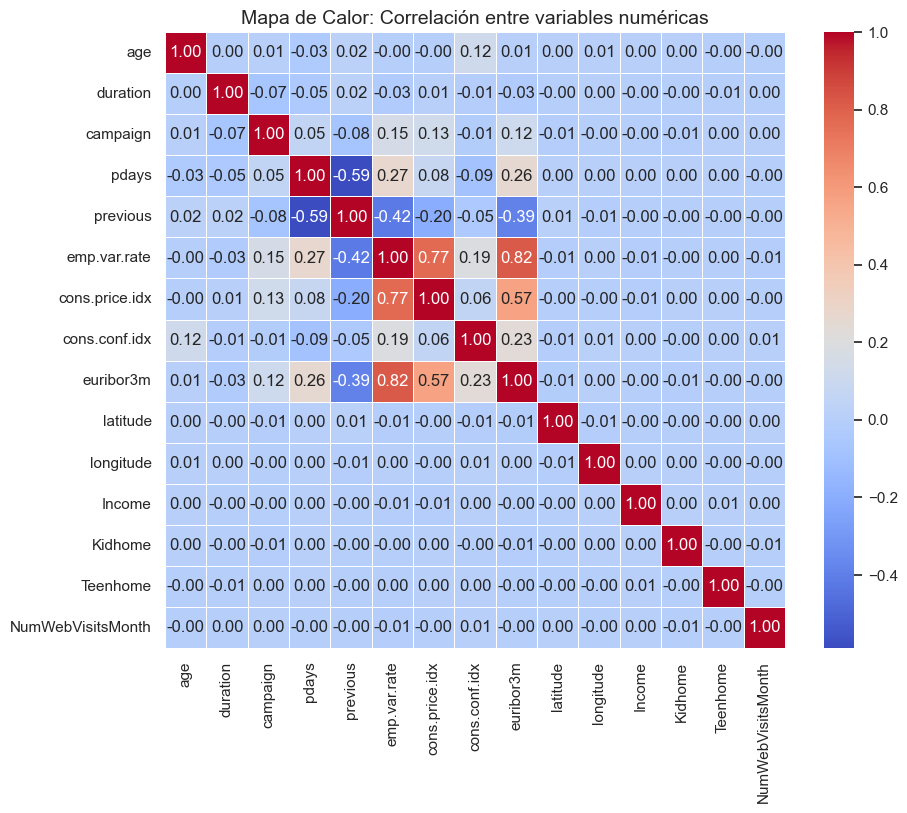

In [24]:
#Importamos la librería para las visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

#Configuración del entorno visual
%matplotlib inline
sns.set_theme(style="whitegrid")

#Generamos un mapa de calor para mostrar correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor: Correlación entre variables numéricas', fontsize=14)
plt.show()

C:\Users\juan_\AppData\Local\Temp\ipykernel_336\3498786908.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ClientesCampañas, x='y', y='Income', palette='viridis', errorbar=None)


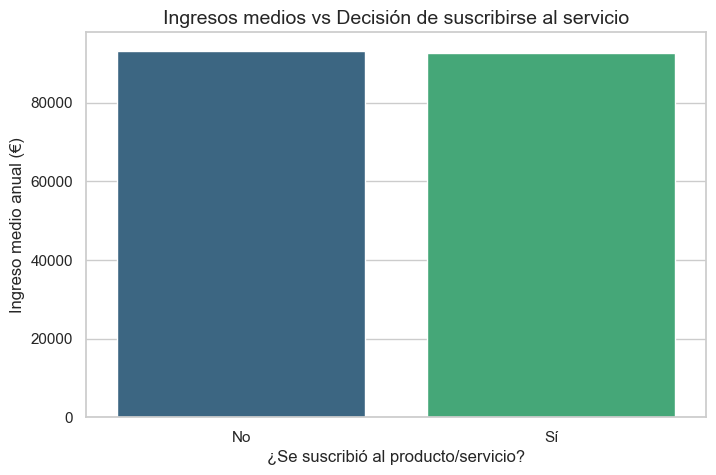

In [25]:
#Gráfico de barras que muestra la media de ingresos segmentada por la decisión del cliente
plt.figure(figsize=(8, 5))
sns.barplot(data=df_ClientesCampañas, x='y', y='Income', palette='viridis', errorbar=None)

#Añadimos las etiquetas y título
plt.title('Ingresos medios vs Decisión de suscribirse al servicio', fontsize=14)
plt.xlabel('¿Se suscribió al producto/servicio?', fontsize=12)
plt.ylabel('Ingreso medio anual (€)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No', 'Sí'])

plt.show()

Se muestra visualmente lo deducido con los datos previos en el que no existe diferencia significativa de ingresos entre los que se suscribieron y los que no

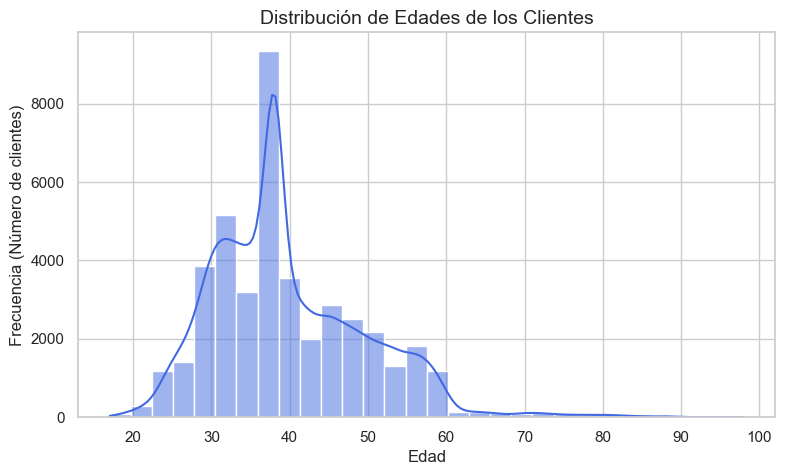

In [26]:
#Histograma para mostrar los grupos de edad que más ingresan en la web 
plt.figure(figsize=(9, 5))
sns.histplot(data=df_ClientesCampañas, x='age', bins=30, kde=True, color='royalblue')

#Añadimos las etiquetas y el título 
plt.title('Distribución de Edades de los Clientes', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia (Número de clientes)', fontsize=12)

plt.show()

El histograma muestra una distribución asimétrica positiva (sesgada a la derecha). 
La densidad principal de clientes se concentra en la franja de los 30 a los 40 años. 
Se observa una caída pronunciada en la frecuencia a partir de los 60 años, aunque, como se detectó en el análisis de variables categóricas, este grupo de mayor edad mantiene una actividad digital recurrente.

In [ ]:
#Una vez realizado el proceso EDA pasamos a la exportación de los datos
#Guardar el DataFrame limpio en la carpeta 'processed'
df_ClientesCampañas.to_csv(r"C:\Users\juan_\Proyecto_EDA_Banco\datos\processed\dataset_banco_limpio.csv", index=False)

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (3321759217.py, line 3)